In [19]:
!pip install numpy pandas matplotlib statsmodels

In [20]:
# ONLY RUN THIS CELL IF USING GOOGLE COLAB

# To add your own Drive Run this cell.
# from google.colab import drive
# drive.mount('/content/gdrive')

In [21]:
# Import packages
# Add more as needed
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROBLEM 2

In [22]:
# Please specify the full paths to Q3 geno and pheno

geno_path_p2 = 'ps2_data/Q2_data/gwas.geno'
pheno_path_p2 = 'ps2_data/Q2_data/gwas.pheno'

In [23]:
# See Q2_data/README for information on these files
gwas_geno = pd.read_csv(geno_path_p2, header=None, sep=' ')
gwas_pheno = pd.read_csv(pheno_path_p2, header=None, sep=' ')

In [24]:
gwas_geno

,0,1,2,3,4,5,6,7,8,9,...,372,373,374,375,376,377,378,379,380,381
0,0,0,2,2,0,1,0,0,1,0,...,1,0,1,0,1,1,0,1,1,1
1,0,0,1,2,1,2,1,0,1,0,...,0,1,1,0,0,1,0,0,0,1
2,0,1,1,2,1,2,0,0,0,0,...,2,1,0,0,1,0,0,0,0,2
3,0,0,2,2,0,2,0,0,1,0,...,2,2,2,1,1,1,0,0,0,2
4,0,0,1,2,1,2,0,0,1,0,...,2,1,2,0,2,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,0,0,2,1,1,2,0,0,2,0,...,1,1,0,0,0,2,0,0,0,1
496,1,0,1,2,0,1,0,1,1,1,...,2,1,2,0,0,1,0,0,0,1
497,0,0,1,2,0,2,0,0,1,0,...,2,2,2,0,0,0,0,0,0,1
498,1,0,2,2,1,1,0,0,2,0,...,2,1,2,0,1,1,0,0,0,1


In [25]:
gwas_pheno

,0,1,2,3
0,-0.325143,0.503856,1.732611,2.092371
1,-0.020982,-0.321068,2.452343,-431.129657
2,-0.371869,-0.216067,0.294997,0.594309
3,-1.477984,-2.209726,4.796187,0.330592
4,0.500458,1.464210,0.318061,0.491238
...,...,...,...,...
495,-0.229760,-1.379190,1.068351,0.086788
496,-0.511328,3.125155,1.592204,0.236867
497,0.214149,0.628176,0.111877,0.142040
498,-0.396145,0.420983,-0.489254,-0.092078


In [26]:
import statsmodels.api as sm

# X: (N samples) x (M SNPs); Y: (N samples) x (K phenotypes)
X = gwas_geno.values.astype(float)
Y = gwas_pheno.values.astype(float)
N, M = X.shape
K = Y.shape[1]

bonferroni_threshold = 0.05 / M

records = []
for k in range(K):
    y = Y[:, k]
    for m in range(M):
        Xm = sm.add_constant(X[:, m])     # prepend column of 1s for intercept
        results = sm.OLS(y, Xm).fit()
        records.append({
            'phenotype':   k,
            'snp':         m,
            'beta0':       results.params[0],
            'beta1':       results.params[1],
            'se_beta1':    results.bse[1],
            't':           results.tvalues[1],
            'p':           results.pvalues[1],
        })

gwas_results = pd.DataFrame(records)
gwas_results['bonferroni_significant'] = gwas_results['p'] < bonferroni_threshold
gwas_results.to_csv('ps2_results/Q2_data/gwas_results.csv', index=False)

print(f"Fit {M} SNPs x {K} phenotypes = {M*K} regressions on N={N} samples")
print(f"Bonferroni threshold (alpha=0.05): p < {bonferroni_threshold:.3e}")
gwas_results.head()

Fit 382 SNPs x 4 phenotypes = 1528 regressions on N=500 samples
Bonferroni threshold (alpha=0.05): p < 1.309e-04


,phenotype,snp,beta0,beta1,se_beta1,t,p,bonferroni_significant
0,0,0,0.057013,0.126740,0.092697,1.367249,0.172164,False
1,0,1,0.058056,0.124563,0.095765,1.300718,0.193956,False
2,0,2,-0.109824,0.123000,0.073692,1.669122,0.095722,False
3,0,3,0.215999,-0.082770,0.074706,-1.107951,0.268418,False
4,0,4,0.048046,0.040012,0.063101,0.634099,0.526307,False


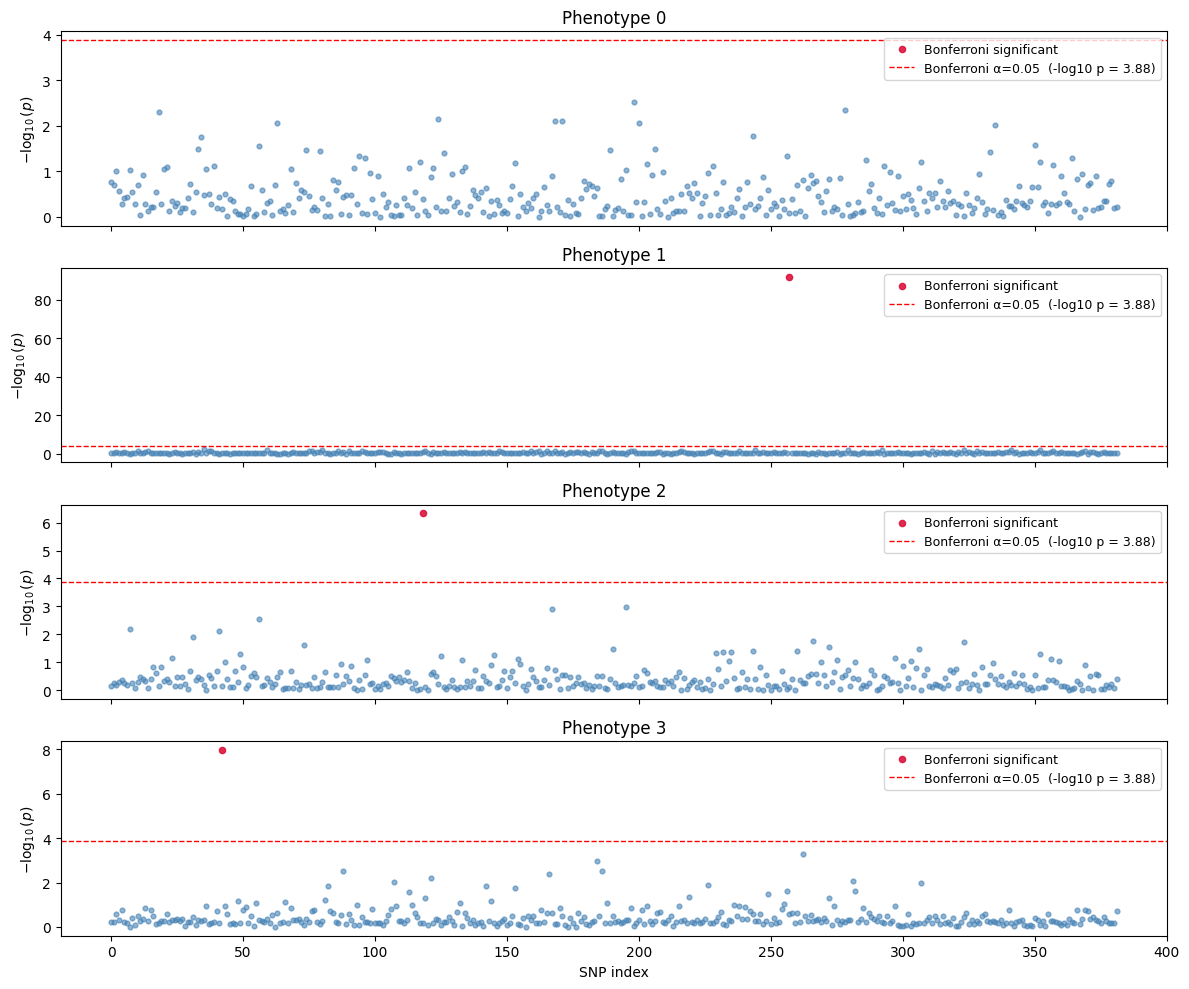

<Figure size 640x480 with 0 Axes>

In [27]:
# Manhattan plots: -log10(p) vs SNP index, one panel per phenotype.
# Red dashed line = Bonferroni threshold (alpha = 0.05 / M).
alpha = 0.05
bonferroni_line = -np.log10(alpha / M)

fig, axes = plt.subplots(K, 1, figsize=(12, 2.5 * K), sharex=True)
for k, ax in enumerate(axes):
    sub = gwas_results[gwas_results['phenotype'] == k]
    neg_log10_p = -np.log10(sub['p'])
    sig = sub['bonferroni_significant']
    ax.scatter(sub['snp'][~sig], neg_log10_p[~sig],
               s=12, alpha=0.6, color='steelblue')
    ax.scatter(sub['snp'][ sig], neg_log10_p[ sig],
               s=20, alpha=0.9, color='crimson', label='Bonferroni significant')
    ax.axhline(bonferroni_line, color='red', linestyle='--', linewidth=1,
               label=f'Bonferroni α=0.05  (-log10 p = {bonferroni_line:.2f})')
    ax.set_ylabel(r'$-\log_{10}(p)$')
    ax.set_title(f'Phenotype {k}')
    ax.legend(loc='upper right', fontsize=9)
axes[-1].set_xlabel('SNP index')
plt.tight_layout()
plt.show()
plt.savefig('ps2_results/Q2_data/manhattan_plots.png', dpi=300, bbox_inches='tight')

/var/folders/10/x8wzn7_n7yg9pv9p71q_4cgc0000gn/T/ipykernel_50134/977692607.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(loc='upper left', fontsize=9)


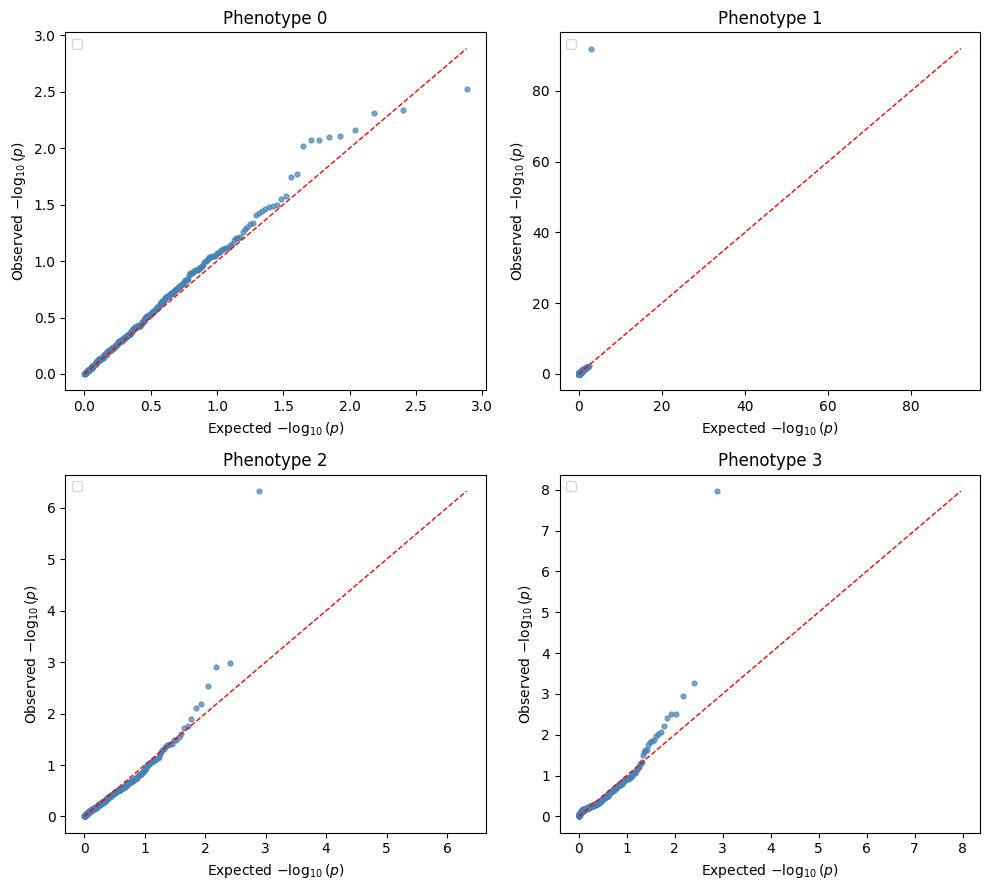

In [37]:
# QQ-PLOTS FOR EACH PHENOTYPE
# QQ-plots: observed -log10(p) vs expected -log10(p) under the null (uniform).
# Points on the diagonal => p-values match the null; upward deviation => signal/inflation.
ncols = 2
nrows = int(np.ceil(K / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.5 * nrows))
axes = np.atleast_1d(axes).flatten()

for k in range(K):
    ax = axes[k]
    sub = gwas_results[gwas_results['phenotype'] == k]
    p_obs = np.sort(sub['p'].values)
    n = len(p_obs)
    p_exp = (np.arange(1, n + 1) - 0.5) / n

    obs = -np.log10(p_obs)
    exp = -np.log10(p_exp)

    ax.scatter(exp, obs, s=12, alpha=0.7, color='steelblue')
    lim = max(exp.max(), obs.max())
    ax.plot([0, lim], [0, lim], color='red', linestyle='--', linewidth=1)
    ax.set_xlabel(r'Expected $-\log_{10}(p)$')
    ax.set_ylabel(r'Observed $-\log_{10}(p)$')
    ax.set_title(f'Phenotype {k}')
    ax.legend(loc='upper left', fontsize=9)

for j in range(K, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('ps2_results/Q2_data/qq_plots.png', dpi=300, bbox_inches='tight')
plt.show()

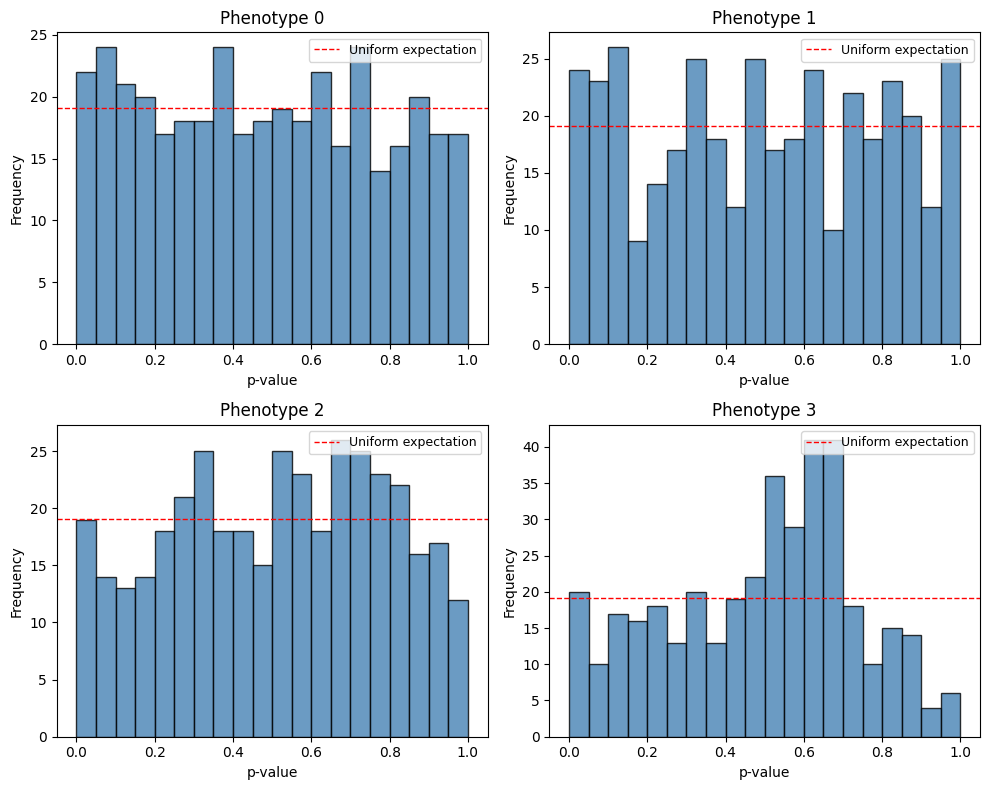

In [29]:
# HISTOGRAMS FOR EACH PHENOTYPE (p-value vs frequency)
# p-value histograms: under the null, p-values are ~Uniform(0,1) => flat histogram.
# A spike near 0 indicates true associations.
ncols = 2
nrows = int(np.ceil(K / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).flatten()

for k in range(K):
    ax = axes[k]
    sub = gwas_results[gwas_results['phenotype'] == k]
    ax.hist(sub['p'].values, bins=20, range=(0, 1),
            color='steelblue', edgecolor='black', alpha=0.8)
    ax.axhline(M / 20, color='red', linestyle='--', linewidth=1,
               label='Uniform expectation')
    ax.set_xlabel('p-value')
    ax.set_ylabel('Frequency')
    ax.set_title(f'Phenotype {k}')
    ax.legend(loc='upper right', fontsize=9)

for j in range(K, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('ps2_results/Q2_data/pvalue_histograms.png', dpi=300, bbox_inches='tight')
plt.show()

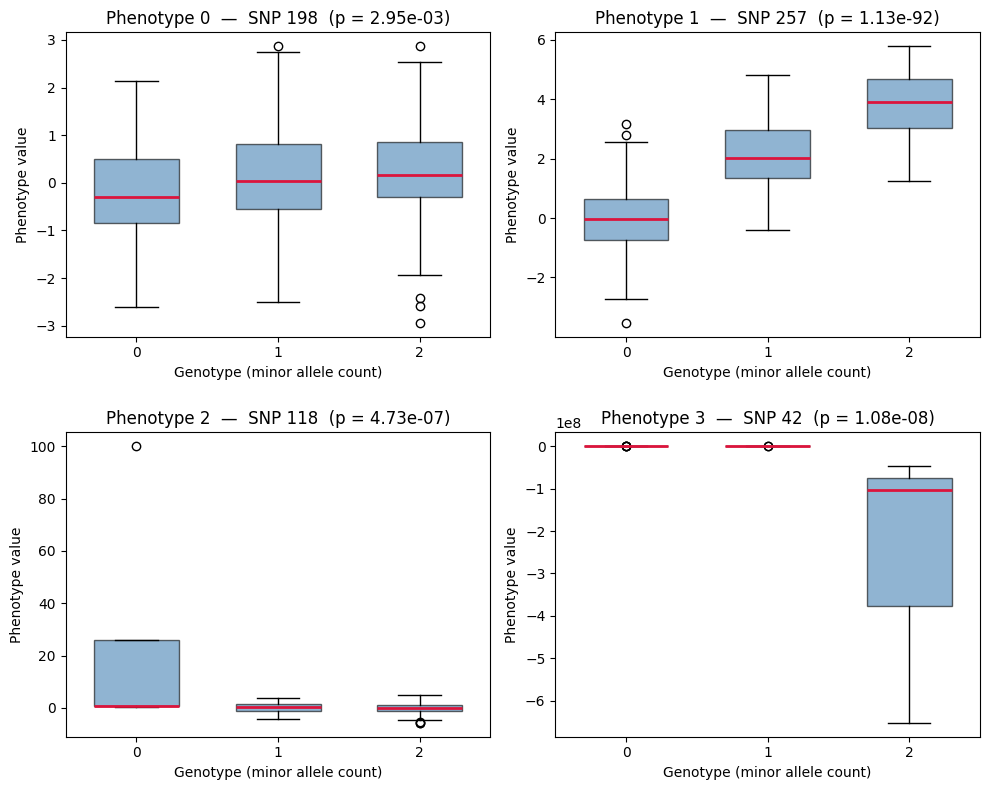

In [39]:
# BOXPLOT FOR PHENOTYPE VS GENOTYPE (Bonferroni-significant SNPs only)
# For each phenotype, plot the distribution of phenotype values stratified by
# genotype (0/1/2 minor alleles) at the most-significant SNP.
ncols = 2
nrows = int(np.ceil(K / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).flatten()

for k in range(K):
    ax = axes[k]
    sub = gwas_results[gwas_results['phenotype'] == k]
    top_snp = int(sub.loc[sub['p'].idxmin(), 'snp'])
    top_p   = sub['p'].min()

    g = X[:, top_snp].astype(int)
    y = Y[:, k]
    groups = [y[g == val] for val in (0, 1, 2)]

    ax.boxplot(groups, tick_labels=['0', '1', '2'], widths=0.6,
               patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6),
               medianprops=dict(color='crimson', linewidth=2))
    ax.set_xlabel('Genotype (minor allele count)')
    ax.set_ylabel('Phenotype value')
    ax.set_title(f'Phenotype {k}  —  SNP {top_snp}  (p = {top_p:.2e})')

for j in range(K, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.savefig('ps2_results/Q2_data/genotype_phenotype_boxplots.png',
            dpi=300, bbox_inches='tight')
plt.show()


PROBLEM 3

In [30]:
# Please specify the full paths to Q3 training/test genos and phenos

geno_train_path_p3 = 'ps2_data/Q3_data/ridge.training.geno'
pheno_train_path_p3 = 'ps2_data/Q3_data/ridge.training.pheno'
geno_test_path_p3 = 'ps2_data/Q3_data/ridge.test.geno'
pheno_test_path_p3 = 'ps2_data/Q3_data/ridge.test.pheno'

In [31]:
# See Q3_data/README for information on these files
ridge_training_geno = pd.read_csv(geno_train_path_p3, header=None, sep=' ')
ridge_training_pheno = pd.read_csv(pheno_train_path_p3, header=None, sep=' ')
ridge_test_geno = pd.read_csv(geno_test_path_p3, header=None, sep=' ')
ridge_test_pheno = pd.read_csv(pheno_test_path_p3, header=None, sep=' ')

In [32]:
ridge_training_geno

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,2,2,1,2,2,1,2,0,1,1,...,1,1,1,0,2,2,1,2,1,2
1,0,2,0,1,1,1,0,0,1,2,...,1,1,0,0,0,1,1,2,2,0
2,2,1,2,0,0,1,0,1,2,1,...,2,2,0,1,0,0,1,1,1,2
3,2,0,0,2,2,2,1,1,2,0,...,1,1,1,1,2,0,1,2,0,2
4,1,2,2,1,0,2,0,1,2,2,...,2,0,0,1,2,2,0,0,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
895,2,0,1,1,2,0,1,1,2,2,...,0,0,1,0,0,0,2,1,2,0
896,2,1,2,2,2,2,1,1,0,1,...,2,1,0,0,2,2,1,2,1,2
897,1,0,1,2,0,1,2,0,0,1,...,2,0,1,0,0,1,1,2,1,1
898,1,1,1,0,2,2,0,1,1,2,...,0,0,0,2,0,1,2,0,2,0


In [33]:
ridge_training_pheno

,0
0,52.0499
1,35.5899
2,31.9954
3,43.0739
4,33.8418
...,...
895,18.7085
896,29.4096
897,66.4829
898,67.1417


In [34]:
ridge_test_geno

,0,1,2,3,4,5,6,7,8,9,...,990,991,992,993,994,995,996,997,998,999
0,1,1,2,1,2,0,0,0,2,1,...,0,1,1,0,2,2,1,1,1,1
1,2,0,0,2,1,0,1,1,1,0,...,0,1,0,1,1,0,1,1,0,1
2,2,1,1,0,0,2,2,0,1,1,...,0,0,0,0,0,0,0,2,2,1
3,0,1,2,1,1,0,0,0,0,2,...,1,0,0,0,1,1,2,0,0,1
4,2,2,1,0,0,1,0,0,2,2,...,2,2,0,0,2,0,1,2,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,1,2,2,2,1,1,2,0,1,...,0,0,1,1,0,2,2,1,0,0
96,1,0,0,1,2,2,1,0,2,1,...,2,0,1,1,0,1,1,2,1,2
97,1,2,1,2,1,2,2,0,2,1,...,1,1,1,2,0,1,1,1,1,2
98,0,1,2,0,0,2,1,0,1,0,...,1,1,0,2,2,2,1,0,1,0


In [35]:
ridge_test_pheno

,0
0,9.0483
1,6.4270
2,-11.5630
3,53.5267
4,58.6365
...,...
95,29.5647
96,16.5643
97,34.8143
98,41.4503


In [36]:
# YOUR SOLUTION HERE